In [140]:
!pip install kagglehub pandas matplotlib seaborn scikit-learn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [141]:
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")
print(path)


C:\Users\LENOVO\.cache\kagglehub\datasets\shashanknecrothapa\ames-housing-dataset\versions\1


In [142]:
print(os.listdir(path))

['AmesHousing.csv']


In [143]:
df = pd.read_csv(os.path.join(path, "AmesHousing.csv"))

In [144]:
df.head(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [145]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [147]:
df.shape

(2930, 82)

In [148]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [149]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


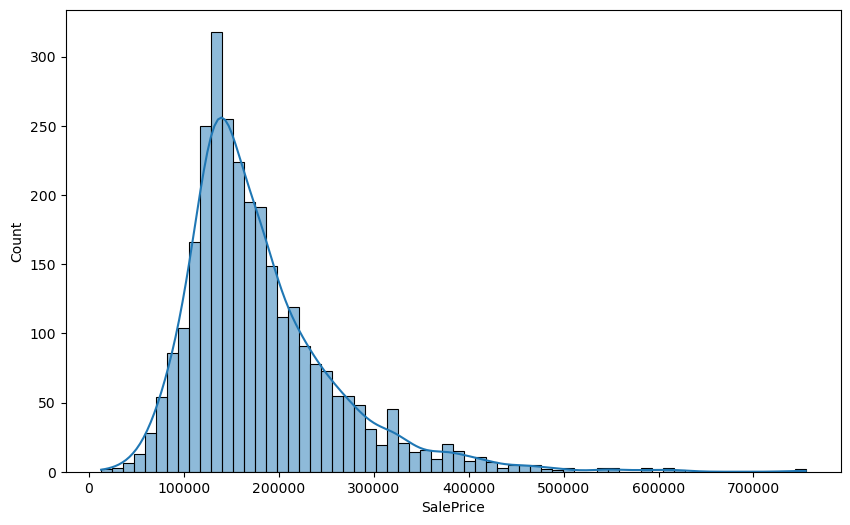

In [150]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], kde=True)
plt.show()

In [151]:
X = df.drop(columns=['SalePrice', 'Order', 'PID'])
X

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal
2926,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal
2927,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
2928,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal


In [152]:
y = df['SalePrice']
y

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2930, dtype: int64

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [154]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
print(numerical_cols)
print(categorical_cols)

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold'],
      dtype='object')
Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exp

In [155]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [156]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [157]:
param = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}

In [158]:
# running k-fold cross validation parameter tuning
ridge_cv = GridSearchCV(SGDRegressor(penalty='l2', max_iter=3000, random_state=42), param, cv=5, scoring='r2')
ridge_cv.fit(X_train_processed, y_train)
best_alpha_ridge = ridge_cv.best_params_['alpha']


lasso_cv = GridSearchCV(SGDRegressor(penalty='l1', max_iter=3000, random_state=42), param, cv=5, scoring='r2')
lasso_cv.fit(X_train_processed, y_train)
best_alpha_lasso = lasso_cv.best_params_['alpha']


elastic_cv = GridSearchCV(SGDRegressor(penalty='elasticnet', l1_ratio=0.5, max_iter=3000, random_state=42), param, cv=5, scoring='r2')
elastic_cv.fit(X_train_processed, y_train)
best_alpha_elastic = elastic_cv.best_params_['alpha']

print(best_alpha_ridge)
print(best_alpha_lasso)
print(best_alpha_elastic)

0.001
10.0
0.01


In [159]:
test_models = {
    "Linear Regression": SGDRegressor(penalty=None, max_iter=2000, random_state=42),
    "Ridge Regression": SGDRegressor(penalty='l2', alpha=0.1, max_iter=2000, random_state=42),
    "Lasso Regression": SGDRegressor(penalty='l1', alpha=0.1, max_iter=2000, random_state=42),
    "Elastic Net Regression": SGDRegressor(penalty='elasticnet', l1_ratio=0.5, alpha=best_alpha_elastic, max_iter=3000, random_state=42)
}

In [160]:
results=[]
for name, model in test_models.items():
    
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    full_pipeline.fit(X_train, y_train)
    
    y_train_pred = full_pipeline.predict(X_train)
    y_test_pred = full_pipeline.predict(X_test)
    

    print(f" MODEL: {name}")
    
    
    metrics = {}
    for label, y_actual, y_predicted in [("train", y_train, y_train_pred), ("test", y_test, y_test_pred)]:
            
            metrics[f'{label}_MAE'] = mean_absolute_error(y_actual, y_predicted)
            metrics[f'{label}_MSE'] = mean_squared_error(y_actual, y_predicted)
            metrics[f'{label}_RMSE'] = np.sqrt(metrics[f'{label}_MSE'])
            metrics[f'{label}_R2'] = r2_score(y_actual, y_predicted)
            
    results.append({
    "Model Name": name,
    "Train MAE": metrics['train_MAE'],
    "Test MAE": metrics['test_MAE'],
    "Train RMSE": metrics['train_RMSE'],
    "Test RMSE": metrics['test_RMSE'],
    "Train R²": metrics['train_R2'],
    "Test R²": metrics['test_R2']
    })
            
            
        

 MODEL: Linear Regression
 MODEL: Ridge Regression
 MODEL: Lasso Regression
 MODEL: Elastic Net Regression


In [161]:
result = pd.DataFrame(results)
display(result)

,Model Name,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression,15045.077211,16764.275761,24191.016514,29082.982394,0.901576,0.894504
1,Ridge Regression,16935.869685,18393.492206,27490.741247,32089.772693,0.872894,0.871563
2,Lasso Regression,15044.998567,16764.017747,24191.572337,29083.049779,0.901571,0.894503
3,Elastic Net Regression,15879.117440,17398.146389,25124.500912,30177.925777,0.893833,0.886411


Here, clearly Lasso Regression emerged as the best regularized model as it achieved a balance between training accuracy and test generalizability.